# Olist E-Commerce Customer Analysis

## Objective

This notebook analyzes customer purchasing behavior in the Olist Brazilian
e-commerce dataset.

The analysis focuses on four main questions:

1. How large is Olist's completed-order customer base?
2. How frequently do customers purchase, and how common are repeat purchases?
3. How is customer value distributed across the marketplace?
4. How can customers be segmented based on recency, frequency, and monetary
   value?

The analysis uses completed orders as the primary transaction scope and relies
on `customer_unique_id` to identify customers across multiple orders.

## 1. Environment Setup

This section imports the libraries required for customer-level data analysis
and defines the project data paths.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_DIR = Path("../data/processed")

## 2. Load Processed Datasets

The customer analysis uses the cleaned relational datasets produced in the
data-cleaning notebook.

The primary datasets required are:

- **Customers:** Maps order-level `customer_id` values to persistent
  `customer_unique_id` values
- **Orders:** Provides order status and purchase timestamps
- **Order Items:** Provides item-level product revenue

In [3]:
customers = pd.read_csv(
    DATA_DIR / "customers.csv"
)

orders = pd.read_csv(
    DATA_DIR / "orders.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

order_items = pd.read_csv(
    DATA_DIR / "order_items.csv",
    parse_dates=["shipping_limit_date"]
)

In [4]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)

Customers: (99441, 8)
Orders: (99441, 8)
Order Items: (112650, 7)


### 2.1 Dataset Preview

A brief preview is used to confirm the available fields and verify that the
processed datasets were loaded correctly.

In [5]:
display(customers.head())
display(orders.head())
display(order_items.head())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_geo_observation_count
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.502307,-47.396740,126.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.730435,-46.541474,125.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531294,-46.656980,34.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.499025,-46.183436,83.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.974331,-47.142173,131.0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## 3. Customer Analysis Definitions

Before constructing customer-level metrics, the customer identifiers and
analysis scope must be clearly defined.

Olist provides two different customer identifiers:

- **`customer_id`:** Identifies the customer record associated with a specific
  order
- **`customer_unique_id`:** Identifies the same underlying customer across
  multiple orders

Because repeat-purchase and customer-lifetime behavior require tracking the
same customer across orders, `customer_unique_id` is used as the primary
customer identifier throughout this notebook.

### 3.1 Validate Customer Identifiers

The customer table is first examined to confirm the behavior of
`customer_id` and `customer_unique_id`.

This validation establishes whether the two identifiers operate at different
grains and confirms which identifier should be used for customer-level
purchase-frequency and repeat-purchase analysis.

In [6]:
print("Customer records:", len(customers))
print("Unique customer_id:", customers["customer_id"].nunique())
print(
    "Unique customer_unique_id:",
    customers["customer_unique_id"].nunique()
)

print(
    "Duplicate customer_id:",
    customers["customer_id"].duplicated().sum()
)

Customer records: 99441
Unique customer_id: 99441
Unique customer_unique_id: 96096
Duplicate customer_id: 0


In [7]:
customer_id_mapping = (
    customers
    .groupby("customer_unique_id")
    .agg(
        customer_records=("customer_id", "nunique")
    )
    .reset_index()
)

customer_id_mapping["customer_records"].describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: customer_records, dtype: float64

In [8]:
customer_id_mapping.sort_values(
    "customer_records",
    ascending=False
).head(10)

,customer_unique_id,customer_records
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
37797,6469f99c1f9dfae7733b25662e7f1782,7
76082,ca77025e7201e3b30c44b472ff346268,7
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,6
83540,de34b16117594161a6a89c50b289d35a,6
37585,63cfc61cee11cbe306bff5857d00bfe4,6
90451,f0e310a6839dce9de1638e0fe5ab282a,6
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,6


### 3.2 Completed-Order Analysis Scope

To remain consistent with the sales analysis, the core customer analysis is
restricted to orders with `order_status == "delivered"`.

This ensures that customer purchase frequency and monetary value are based on
successfully completed transactions rather than canceled, unavailable, or
unfinished orders.

In [9]:
completed_orders = (
    orders.loc[orders["order_status"] == "delivered"]
    .copy()
)

print("Completed orders:", len(completed_orders))
print(
    "Unique completed order IDs:",
    completed_orders["order_id"].nunique()
)

Completed orders: 96478
Unique completed order IDs: 96478


### 3.3 Attach Persistent Customer Identifiers

Completed orders are joined to the customer table through `customer_id`.

The join adds `customer_unique_id`, allowing multiple order-level customer
records to be linked back to the same underlying customer.

Because each `customer_id` appears only once in the customer dataset, this is a
many-to-one join from orders to customers.

In [10]:
customer_orders = completed_orders.merge(
    customers[
        [
            "customer_id",
            "customer_unique_id",
            "customer_city",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [11]:
print("Completed orders before merge:", len(completed_orders))
print("Customer orders after merge:", len(customer_orders))

print(
    "Missing customer_unique_id:",
    customer_orders["customer_unique_id"].isna().sum()
)

print(
    "Unique completed-order customers:",
    customer_orders["customer_unique_id"].nunique()
)

Completed orders before merge: 96478
Customer orders after merge: 96478
Missing customer_unique_id: 0
Unique completed-order customers: 93358


In [12]:
print(
    "Unique order IDs:",
    customer_orders["order_id"].nunique()
)

print(
    "Duplicate order IDs:",
    customer_orders["order_id"].duplicated().sum()
)

Unique order IDs: 96478
Duplicate order IDs: 0


#### Customer Identifier and Analysis Scope — Key Findings

The customer dataset contains **99,441 order-level customer records** and
**96,096 unique `customer_unique_id` values**.

Each `customer_id` is unique, while some `customer_unique_id` values are linked
to multiple customer records. The median customer is associated with one
customer record, while the maximum observed value is **17 records** for a
single `customer_unique_id`.

This confirms that `customer_id` should not be used to measure repeat customer
behavior across orders. Instead, `customer_unique_id` is used as the persistent
customer identifier throughout the analysis.

After restricting the analysis to delivered orders, **96,478 completed orders**
were successfully linked to **93,358 unique customers**.

The customer join preserved all completed orders, introduced no duplicate order
records, and produced no missing `customer_unique_id` values. Therefore, the
resulting `customer_orders` dataset maintains a grain of **one row per completed
order** and can be safely used for customer purchase-frequency analysis.

## 4. Customer Base & Purchase Frequency

This section examines the number of completed orders placed by each unique
customer.

Purchase frequency is calculated using `customer_unique_id`, allowing multiple
completed orders associated with the same underlying customer to be grouped
together.

The analysis first evaluates the overall distribution of completed orders per
customer before distinguishing between one-time and repeat customers.

### 4.1 Completed Orders per Customer

Completed orders are aggregated by `customer_unique_id` to measure how many
successfully delivered orders each customer placed during the observed dataset
period.

In [13]:
customer_frequency = (
    customer_orders
    .groupby("customer_unique_id")
    .agg(
        completed_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [14]:
print("Customer frequency records:", len(customer_frequency))

print(
    "Unique customers in customer_orders:",
    customer_orders["customer_unique_id"].nunique()
)

print(
    "Total completed orders after aggregation:",
    customer_frequency["completed_orders"].sum()
)

Customer frequency records: 93358
Unique customers in customer_orders: 93358
Total completed orders after aggregation: 96478


#### 4.1.1 Purchase Frequency Distribution

In [15]:
purchase_frequency_distribution = (
    customer_frequency["completed_orders"]
    .value_counts()
    .sort_index()
    .rename_axis("completed_orders")
    .reset_index(name="customers")
)

purchase_frequency_distribution["customer_share_pct"] = (
    purchase_frequency_distribution["customers"]
    / len(customer_frequency)
    * 100
)

purchase_frequency_distribution

,completed_orders,customers,customer_share_pct
0,1,90557,96.999722
1,2,2573,2.756057
2,3,181,0.193877
3,4,28,0.029992
4,5,9,0.009640
5,6,5,0.005356
6,7,3,0.003213
7,9,1,0.001071
8,15,1,0.001071


In [16]:
print(
    "Customers represented in frequency distribution:",
    purchase_frequency_distribution["customers"].sum()
)

print(
    "Completed orders represented in frequency distribution:",
    (
        purchase_frequency_distribution["completed_orders"]
        * purchase_frequency_distribution["customers"]
    ).sum()
)

Customers represented in frequency distribution: 93358
Completed orders represented in frequency distribution: 96478


#### Purchase Frequency Distribution — Key Findings

The completed-order customer base consists of **93,358 unique customers**
associated with **96,478 completed orders**.

Purchase frequency is highly concentrated among one-time customers.
Approximately **97.00%** of customers placed only **one completed order**
during the observed dataset period.

Only a small proportion of customers placed multiple completed orders:

- **2.76%** of customers placed two completed orders
- Approximately **0.19%** placed three completed orders
- Customers with four or more completed orders represented only a very small
  share of the customer base

The highest observed purchase frequency was **15 completed orders** for a
single customer.

These results indicate that repeat purchasing was relatively uncommon within
the observed completed-order customer base.

### 4.2 One-Time vs Repeat Customers

To evaluate customer retention behavior, customers are divided into two groups
based on their number of completed orders:

- **One-Time Customer:** Exactly one completed order
- **Repeat Customer:** Two or more completed orders

This classification provides a simple measure of how frequently customers
returned to place another successfully completed order during the observed
dataset period.

In [17]:
customer_frequency["customer_type"] = np.where(
    customer_frequency["completed_orders"] == 1,
    "One-Time Customer",
    "Repeat Customer"
)

In [18]:
customer_type_summary = (
    customer_frequency["customer_type"]
    .value_counts()
    .rename_axis("customer_type")
    .reset_index(name="customers")
)

customer_type_summary["customer_share_pct"] = (
    customer_type_summary["customers"]
    / len(customer_frequency)
    * 100
)

customer_type_summary

,customer_type,customers,customer_share_pct
0,One-Time Customer,90557,96.999722
1,Repeat Customer,2801,3.000278


#### 4.2.1 Repeat Purchase Rate

The repeat purchase rate measures the proportion of completed-order customers
who placed at least two completed orders during the observed dataset period.

It is calculated as:

**Repeat Purchase Rate = Repeat Customers / Total Completed-Order Customers**

In [19]:
repeat_customers = (
    customer_frequency["completed_orders"] >= 2
).sum()

total_customers = len(customer_frequency)

repeat_purchase_rate = (
    repeat_customers / total_customers * 100
)

print("Total completed-order customers:", total_customers)
print("Repeat customers:", repeat_customers)
print(
    f"Repeat purchase rate: {repeat_purchase_rate:.2f}%"
)

Total completed-order customers: 93358
Repeat customers: 2801
Repeat purchase rate: 3.00%


#### 4.2.2 Completed Orders by Customer Type

Customer counts alone do not show how much transaction activity each customer
group contributes.

Completed orders are therefore aggregated by customer type to compare the
order contribution of one-time and repeat customers.

In [20]:
customer_type_orders = (
    customer_frequency
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "nunique"),
        completed_orders=("completed_orders", "sum")
    )
    .reset_index()
)

customer_type_orders["customer_share_pct"] = (
    customer_type_orders["customers"]
    / customer_type_orders["customers"].sum()
    * 100
)

customer_type_orders["order_share_pct"] = (
    customer_type_orders["completed_orders"]
    / customer_type_orders["completed_orders"].sum()
    * 100
)

customer_type_orders

,customer_type,customers,completed_orders,customer_share_pct,order_share_pct
0,One-Time Customer,90557,90557,96.999722,93.86285
1,Repeat Customer,2801,5921,3.000278,6.13715


In [21]:
print(
    "Customers represented:",
    customer_type_orders["customers"].sum()
)

print(
    "Completed orders represented:",
    customer_type_orders["completed_orders"].sum()
)

Customers represented: 93358
Completed orders represented: 96478


#### One-Time vs Repeat Customers — Key Findings

Olist's completed-order customer base is heavily concentrated among one-time
customers.

Of the **93,358 unique customers** with at least one completed order,
**90,557 customers (97.00%)** placed exactly one completed order, while only
**2,801 customers (3.00%)** placed two or more completed orders during the
observed dataset period.

Although repeat customers represented only **3.00%** of the customer base,
they accounted for **5,921 completed orders**, or approximately **6.14%** of
all completed orders. In comparison, one-time customers generated
**90,557 completed orders**, representing approximately **93.86%** of completed
orders.

The repeat-customer order share is therefore roughly twice their customer
share, reflecting the additional purchases generated by this relatively small
group.

Overall, the observed completed-order customer base is strongly driven by
one-time purchasing, with repeat purchasing representing a relatively small
share of both customers and transaction activity.

### 4.3 Customer Purchase Frequency Visualization

The customer base is highly concentrated among customers with only one
completed order.

To make this imbalance easier to interpret, customers are visualized as
one-time and repeat customers rather than across every individual purchase
frequency.

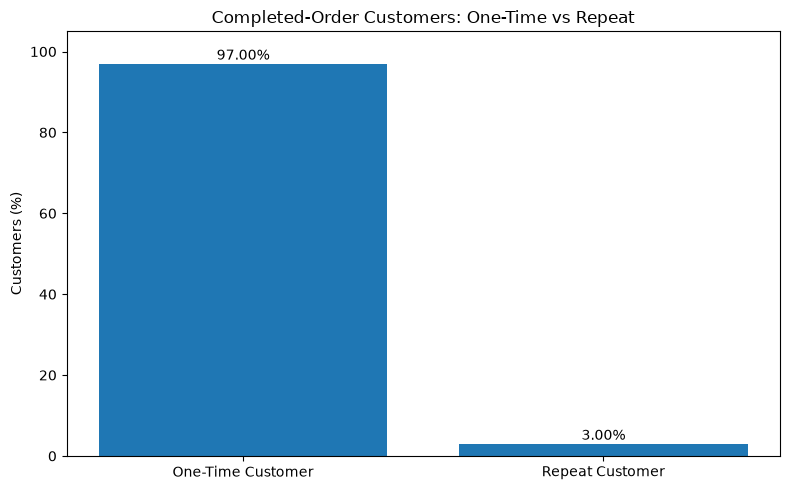

In [22]:
customer_type_plot = (
    customer_type_summary
    .set_index("customer_type")
    .loc[["One-Time Customer", "Repeat Customer"]]
    .reset_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_type_plot["customer_type"],
    customer_type_plot["customer_share_pct"]
)

plt.ylabel("Customers (%)")
plt.title("Completed-Order Customers: One-Time vs Repeat")
plt.ylim(0, 105)

for bar, value in zip(
    bars,
    customer_type_plot["customer_share_pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Customer Purchase Frequency Visualization — Key Findings

The visualization highlights the strong imbalance between one-time and repeat
customers.

Approximately **97.00%** of completed-order customers placed only one completed
order, while just **3.00%** returned to place at least one additional completed
order during the observed dataset period.

This confirms that repeat purchasing was limited within the available
transaction history and that the completed-order customer base was
predominantly composed of one-time purchasers.

## 5. Repeat Purchase Analysis

The previous section showed that only a small share of customers placed more
than one completed order during the observed dataset period.

This section focuses specifically on repeat customers to examine how frequently
they purchased and how much time elapsed between their first and second
completed purchases.

The analysis uses `customer_unique_id` to track purchasing behavior across
multiple completed orders.

### 5.1 Repeat Customer Purchase Frequency

Repeat customers are defined as customers with at least two completed orders.

Their purchase-frequency distribution is examined to determine whether repeat
behavior is primarily limited to a second purchase or extends to customers with
multiple additional purchases.

In [23]:
repeat_customer_frequency = (
    customer_frequency.loc[
        customer_frequency["completed_orders"] >= 2
    ]
    .copy()
)

print(
    "Repeat customers:",
    len(repeat_customer_frequency)
)

repeat_customer_frequency["completed_orders"].describe()

Repeat customers: 2801


count    2801.000000
mean        2.113888
std         0.503796
min         2.000000
25%         2.000000
50%         2.000000
75%         2.000000
max        15.000000
Name: completed_orders, dtype: float64

In [24]:
repeat_frequency_distribution = (
    repeat_customer_frequency["completed_orders"]
    .value_counts()
    .sort_index()
    .rename_axis("completed_orders")
    .reset_index(name="repeat_customers")
)

repeat_frequency_distribution["repeat_customer_share_pct"] = (
    repeat_frequency_distribution["repeat_customers"]
    / len(repeat_customer_frequency)
    * 100
)

repeat_frequency_distribution

,completed_orders,repeat_customers,repeat_customer_share_pct
0,2,2573,91.860050
1,3,181,6.461978
2,4,28,0.999643
3,5,9,0.321314
4,6,5,0.178508
5,7,3,0.107105
6,9,1,0.035702
7,15,1,0.035702


#### 5.1.1 Two Orders vs Three or More

In [25]:
repeat_customer_frequency["repeat_depth"] = np.where(
    repeat_customer_frequency["completed_orders"] == 2,
    "Exactly 2 Orders",
    "3+ Orders"
)

repeat_depth_summary = (
    repeat_customer_frequency["repeat_depth"]
    .value_counts()
    .rename_axis("repeat_depth")
    .reset_index(name="customers")
)

repeat_depth_summary["repeat_customer_share_pct"] = (
    repeat_depth_summary["customers"]
    / repeat_depth_summary["customers"].sum()
    * 100
)

repeat_depth_summary

,repeat_depth,customers,repeat_customer_share_pct
0,Exactly 2 Orders,2573,91.86005
1,3+ Orders,228,8.13995


#### Repeat Customer Purchase Frequency — Key Findings

Among the **2,801 repeat customers**, repeat purchasing was strongly
concentrated around a second completed order.

A total of **2,573 repeat customers (91.86%)** placed exactly **two completed
orders**, while only **228 customers (8.14%)** placed **three or more completed
orders** during the observed dataset period.

The median repeat customer placed **two completed orders**, and the mean was
approximately **2.11 orders**. Although the maximum observed purchase frequency
was **15 completed orders**, customers with higher purchase frequencies were
rare.

These results indicate that even among customers who returned after their
initial completed purchase, sustained repeat purchasing beyond a second order
was relatively uncommon within the observed transaction history.

### 5.2 Time to Second Purchase

Purchase frequency shows whether customers returned, but it does not indicate
how quickly repeat purchasing occurred.

This section measures the number of days between each repeat customer's first
and second completed purchases.

Only customers with at least two completed orders are included. Orders are
sorted chronologically using `order_purchase_timestamp`, and the first two
completed purchases are identified for each `customer_unique_id`.

#### 5.2.1 Identify First and Second Completed Purchases

In [26]:
repeat_customer_ids = repeat_customer_frequency[
    "customer_unique_id"
]

repeat_customer_orders = (
    customer_orders.loc[
        customer_orders["customer_unique_id"].isin(
            repeat_customer_ids
        )
    ]
    .sort_values(
        ["customer_unique_id", "order_purchase_timestamp", "order_id"]
    )
    .copy()
)

In [27]:
repeat_customer_orders["purchase_number"] = (
    repeat_customer_orders
    .groupby("customer_unique_id")
    .cumcount() + 1
)

In [28]:
print(
    "Repeat customers:",
    repeat_customer_orders["customer_unique_id"].nunique()
)

print(
    "Repeat-customer completed orders:",
    len(repeat_customer_orders)
)

repeat_customer_orders["purchase_number"].describe()

Repeat customers: 2801
Repeat-customer completed orders: 5921


count    5921.000000
mean        1.616957
std         0.785560
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max        15.000000
Name: purchase_number, dtype: float64

#### 5.2.2 Construct First-to-Second Purchase Dataset

In [29]:
first_second_orders = (
    repeat_customer_orders.loc[
        repeat_customer_orders["purchase_number"].isin([1, 2]),
        [
            "customer_unique_id",
            "purchase_number",
            "order_purchase_timestamp"
        ]
    ]
    .pivot(
        index="customer_unique_id",
        columns="purchase_number",
        values="order_purchase_timestamp"
    )
    .reset_index()
    .rename(
        columns={
            1: "first_purchase_timestamp",
            2: "second_purchase_timestamp"
        }
    )
)

In [30]:
first_second_orders.head()

purchase_number,customer_unique_id,first_purchase_timestamp,second_purchase_timestamp
0,004288347e5e88a27ded2bb23747066c,2017-07-27 14:13:03,2018-01-14 07:36:54
1,00a39521eb40f7012db50455bf083460,2018-05-23 20:14:21,2018-06-03 10:12:57
2,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:22,2017-03-21 19:25:23
3,011575986092c30523ecb71ff10cb473,2018-02-17 15:54:49,2018-04-18 21:58:08
4,011b4adcd54683b480c4d841250a987f,2017-08-22 12:51:29,2018-02-15 11:40:57


#### 5.2.3 Validate First and Second Purchases

In [31]:
print(
    "Repeat customers in timing analysis:",
    len(first_second_orders)
)

print(
    "Missing first purchase:",
    first_second_orders["first_purchase_timestamp"].isna().sum()
)

print(
    "Missing second purchase:",
    first_second_orders["second_purchase_timestamp"].isna().sum()
)

print(
    "Second purchase before first purchase:",
    (
        first_second_orders["second_purchase_timestamp"]
        < first_second_orders["first_purchase_timestamp"]
    ).sum()
)

Repeat customers in timing analysis: 2801
Missing first purchase: 0
Missing second purchase: 0
Second purchase before first purchase: 0


#### 5.2.4 Calculate Days to Second Purchase

In [32]:
first_second_orders["days_to_second_purchase"] = (
    first_second_orders["second_purchase_timestamp"]
    - first_second_orders["first_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

In [33]:
first_second_orders["days_to_second_purchase"].describe()

count    2801.000000
mean       81.206685
std       110.004017
min         0.000000
25%         0.002130
50%        28.980197
75%       126.263588
max       608.978912
Name: days_to_second_purchase, dtype: float64

In [34]:
print(
    "Same-timestamp repeat purchases:",
    (
        first_second_orders["days_to_second_purchase"] == 0
    ).sum()
)

print(
    "Negative purchase intervals:",
    (
        first_second_orders["days_to_second_purchase"] < 0
    ).sum()
)

Same-timestamp repeat purchases: 253
Negative purchase intervals: 0


#### 5.2.5 Very Short Purchase Interval Validation

The initial distribution shows a substantial number of very short intervals
between customers' first and second completed orders.

Because multiple orders placed within a very short period may represent the
same shopping session rather than a conventional return purchase, these
intervals are examined separately before interpreting customer repurchase
timing.

The original completed orders are retained. This analysis does not remove or
reclassify transactions; it evaluates how sensitive the repurchase-timing
metric is to very short purchase intervals.

In [35]:
short_interval_summary = pd.DataFrame({
    "interval": [
        "Same Timestamp",
        "Within 1 Minute",
        "Within 10 Minutes",
        "Within 1 Hour",
        "Within 24 Hours",
        "Within 7 Days",
        "Within 30 Days"
    ],
    "customers": [
        (first_second_orders["days_to_second_purchase"] == 0).sum(),
        (first_second_orders["days_to_second_purchase"] <= 1 / (24 * 60)).sum(),
        (first_second_orders["days_to_second_purchase"] <= 10 / (24 * 60)).sum(),
        (first_second_orders["days_to_second_purchase"] <= 1 / 24).sum(),
        (first_second_orders["days_to_second_purchase"] <= 1).sum(),
        (first_second_orders["days_to_second_purchase"] <= 7).sum(),
        (first_second_orders["days_to_second_purchase"] <= 30).sum()
    ]
})

short_interval_summary["repeat_customer_share_pct"] = (
    short_interval_summary["customers"]
    / len(first_second_orders)
    * 100
)

short_interval_summary

,interval,customers,repeat_customer_share_pct
0,Same Timestamp,253,9.032488
1,Within 1 Minute,685,24.455552
2,Within 10 Minutes,737,26.312031
3,Within 1 Hour,797,28.454124
4,Within 24 Hours,853,30.453409
5,Within 7 Days,1015,36.237058
6,Within 30 Days,1412,50.410568


In [36]:
first_second_orders["seconds_to_second_purchase"] = (
    first_second_orders["second_purchase_timestamp"]
    - first_second_orders["first_purchase_timestamp"]
).dt.total_seconds()

In [37]:
first_second_orders[
    "seconds_to_second_purchase"
].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50]
)

count    2.801000e+03
mean     7.016258e+06
std      9.504347e+06
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
10%      1.000000e+00
25%      1.840000e+02
50%      2.503889e+06
max      5.261578e+07
Name: seconds_to_second_purchase, dtype: float64

In [38]:
first_second_orders[
    [
        "customer_unique_id",
        "first_purchase_timestamp",
        "second_purchase_timestamp",
        "seconds_to_second_purchase",
        "days_to_second_purchase"
    ]
].sort_values(
    "seconds_to_second_purchase"
).head(20)

purchase_number,customer_unique_id,first_purchase_timestamp,second_purchase_timestamp,seconds_to_second_purchase,days_to_second_purchase
2800,ffe254cc039740e17dd15a5305035928,2017-04-02 16:33:30,2017-04-02 16:33:30,0.0,0.0
726,444afd392665f1cc1f3b65ec48063735,2018-02-21 07:41:25,2018-02-21 07:41:25,0.0,0.0
2183,c50794dfc62b62a84f72475abf38b4e3,2018-07-17 08:58:47,2018-07-17 08:58:47,0.0,0.0
2188,c5b58e89d4e287e453b4a0bffcf7a025,2017-07-28 10:51:19,2017-07-28 10:51:19,0.0,0.0
2198,c73f294466cf13293810f4d1a3728d56,2018-07-28 13:20:43,2018-07-28 13:20:43,0.0,0.0
700,415b073d153528fa1ed35a42e39945da,2018-06-30 11:02:45,2018-06-30 11:02:45,0.0,0.0
2234,ca994abc57b0bd7981d91d0061b3d8d6,2017-07-13 21:03:44,2017-07-13 21:03:44,0.0,0.0
2262,cd52ca09554e5cc34d9ec28d230008af,2018-03-21 09:40:36,2018-03-21 09:40:36,0.0,0.0
658,3d4cd13fd525234c1c4a2304fbe769e0,2017-12-12 23:41:30,2017-12-12 23:41:30,0.0,0.0
2267,cddc66766972c6d5da2fdd80fcefe1f0,2018-03-21 14:03:09,2018-03-21 14:03:09,0.0,0.0


In [39]:
same_timestamp_orders = (
    repeat_customer_orders
    .groupby(
        [
            "customer_unique_id",
            "order_purchase_timestamp"
        ]
    )
    .agg(
        distinct_orders=("order_id", "nunique")
    )
    .reset_index()
)

same_timestamp_multiple_orders = (
    same_timestamp_orders.loc[
        same_timestamp_orders["distinct_orders"] > 1
    ]
    .sort_values(
        "distinct_orders",
        ascending=False
    )
)

print(
    "Customer-timestamp combinations with multiple orders:",
    len(same_timestamp_multiple_orders)
)

same_timestamp_multiple_orders.head(10)

Customer-timestamp combinations with multiple orders: 265


,customer_unique_id,order_purchase_timestamp,distinct_orders
2237,66980c3775537536f77b434d74e520f5,2018-03-31 15:08:21,3
5011,e13e8b789e5a8e6fe1445f924a4ed4f6,2018-06-01 13:39:44,3
38,02b20b7c813efede140142ac610e36dc,2018-03-19 20:50:39,2
3792,a982bd0fec12d781fecd9f1e17cb81bf,2018-02-25 17:37:04,2
3895,ae53a87a257f8e54795af6ff434e443b,2017-09-14 10:12:04,2
3890,ae4395be33e633d0c87010d59847e5ed,2018-05-18 00:35:08,2
3876,addc1082e059523e5ef2e7486d1d8905,2018-02-27 10:08:49,2
3837,abfe742e782fb10f5c824fcb849e5cd1,2017-08-18 14:30:22,2
3829,ab63cccdc1367499b533e102cc9631d5,2018-07-08 19:40:11,2
3764,a7f45c1961dbd98e7a14f3d38ea11c06,2018-07-18 15:03:36,2


#### Time to Second Purchase — Key Findings

Among the **2,801 repeat customers**, the median time between the first and
second completed purchases was approximately **28.98 days**, while the mean
was substantially higher at approximately **81.21 days**.

The difference between the median and mean, together with a maximum interval
of approximately **608.98 days**, indicates a strongly right-skewed
distribution of second-purchase timing.

However, a substantial share of second completed orders occurred very shortly
after the first:

- **9.03%** occurred at exactly the same recorded purchase timestamp
- **24.46%** occurred within one minute
- **28.45%** occurred within one hour
- **30.45%** occurred within 24 hours
- **50.41%** occurred within 30 days

Further validation identified **265 customer–timestamp combinations** containing
multiple distinct completed orders at the same recorded purchase time.

These records are retained because they represent distinct orders in the
dataset. However, very short intervals may reflect multiple orders placed
within the same shopping session rather than a conventional return purchase.

For this reason, the median provides a more robust summary of the observed
time to second completed purchase than the mean, but the timing metric should
be interpreted with this short-interval behavior in mind.

#### 5.2.6 Cumulative Time to Second Purchase

Because time to second purchase is strongly right-skewed and includes a large
concentration of very short intervals, a cumulative distribution is used to
show the proportion of repeat customers who placed their second completed
order within a given number of days.

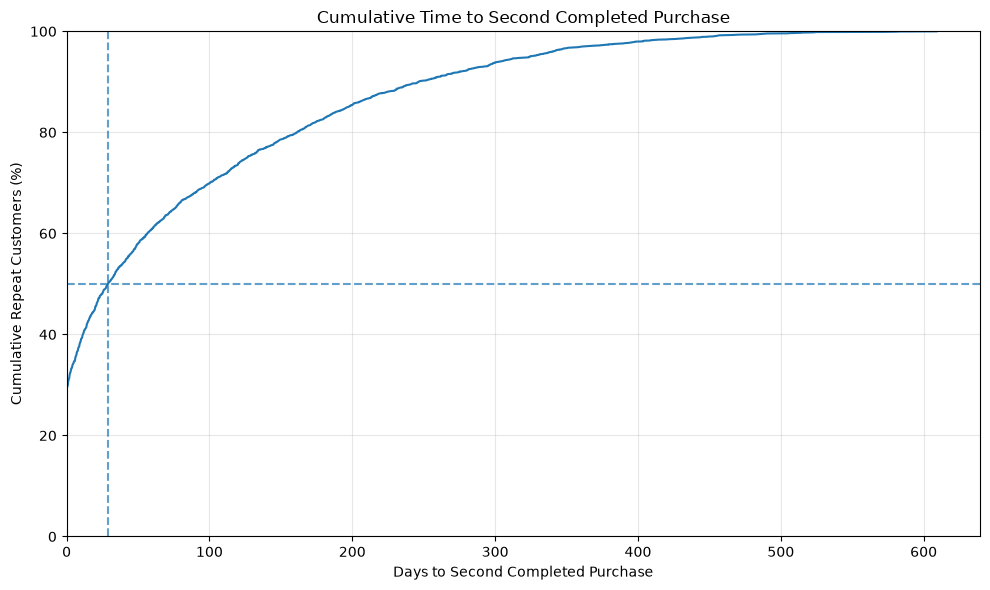

In [40]:
second_purchase_timing = (
    first_second_orders["days_to_second_purchase"]
    .sort_values()
    .reset_index(drop=True)
)

cumulative_customer_pct = (
    (second_purchase_timing.index + 1)
    / len(second_purchase_timing)
    * 100
)

plt.figure(figsize=(10, 6))

plt.plot(
    second_purchase_timing,
    cumulative_customer_pct
)

plt.axhline(
    50,
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    first_second_orders["days_to_second_purchase"].median(),
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Days to Second Completed Purchase")
plt.ylabel("Cumulative Repeat Customers (%)")
plt.title("Cumulative Time to Second Completed Purchase")
plt.xlim(left=0)
plt.ylim(0, 100)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Cumulative Second-Purchase Timing — Key Findings

The cumulative distribution shows that second completed purchases occurred
across a wide range of time intervals.

Among repeat customers:

- **30.45%** placed their second completed order within **1 day**
- **36.24%** did so within **7 days**
- **50.41%** did so within **30 days**
- **68.08%** did so within **90 days**
- **82.68%** did so within **180 days**

The cumulative distribution reaches approximately 50% at around **29 days**,
consistent with the median time to second completed purchase of approximately
**28.98 days**.

However, the steep rise near the beginning of the curve reflects the large
number of very short purchase intervals identified earlier. Therefore, these
results describe the timing between distinct completed orders and should not
be interpreted entirely as conventional customer return behavior.

In [41]:
timing_milestones = pd.DataFrame({
    "time_window": [
        "Within 1 Day",
        "Within 7 Days",
        "Within 30 Days",
        "Within 90 Days",
        "Within 180 Days"
    ],
    "repeat_customers": [
        (first_second_orders["days_to_second_purchase"] <= 1).sum(),
        (first_second_orders["days_to_second_purchase"] <= 7).sum(),
        (first_second_orders["days_to_second_purchase"] <= 30).sum(),
        (first_second_orders["days_to_second_purchase"] <= 90).sum(),
        (first_second_orders["days_to_second_purchase"] <= 180).sum()
    ]
})

timing_milestones["repeat_customer_share_pct"] = (
    timing_milestones["repeat_customers"]
    / len(first_second_orders)
    * 100
)

timing_milestones

,time_window,repeat_customers,repeat_customer_share_pct
0,Within 1 Day,853,30.453409
1,Within 7 Days,1015,36.237058
2,Within 30 Days,1412,50.410568
3,Within 90 Days,1907,68.082828
4,Within 180 Days,2316,82.684755


#### Observation Window Consideration

Repeat-purchase metrics are influenced by the finite observation period of the
dataset.

Customers whose first purchase occurred earlier in the dataset had more time
to place another order than customers whose first purchase occurred near the
end of the available transaction history.

Therefore, the **3.00% repeat purchase rate** should be interpreted as the
observed share of customers with multiple completed orders within the available
dataset period rather than as a long-term customer retention rate.

Similarly, time-to-second-purchase metrics describe only customers for whom a
second completed purchase was observed and should not be generalized to the
entire customer base.

## 6. Customer Value Analysis

Purchase frequency describes how often customers buy, but it does not show
how much economic value they generate.

This section combines completed-order customer data with item-level product
revenue to evaluate customer monetary value.

The analysis focuses on:

- Total product revenue generated by each customer
- Revenue contribution of one-time and repeat customers
- Revenue per customer
- Distribution and concentration of customer value

Product revenue is defined consistently with the sales analysis as the sum of
item-level `price` values from completed orders. Freight charges are excluded
from the customer monetary-value metric.

### 6.1 Construct Order-Level Product Revenue

Order items are first aggregated to the order level before being joined to
customer data.

This prevents item-level rows from multiplying order-level customer records
and preserves a clear analytical grain.

For each completed order, product revenue is calculated as the sum of item
prices associated with that order.

In [42]:
completed_order_ids = customer_orders["order_id"]

completed_order_items = (
    order_items.loc[
        order_items["order_id"].isin(completed_order_ids)
    ]
    .copy()
)

print("Completed-order item records:", len(completed_order_items))
print(
    "Completed orders represented in items:",
    completed_order_items["order_id"].nunique()
)

Completed-order item records: 110197
Completed orders represented in items: 96478


In [43]:
order_revenue = (
    completed_order_items
    .groupby("order_id")
    .agg(
        product_revenue=("price", "sum"),
        items_purchased=("order_item_id", "count")
    )
    .reset_index()
)

In [44]:
print("Order revenue records:", len(order_revenue))
print(
    "Unique order IDs:",
    order_revenue["order_id"].nunique()
)
print(
    f"Total product revenue: "
    f"R${order_revenue['product_revenue'].sum():,.2f}"
)

Order revenue records: 96478
Unique order IDs: 96478
Total product revenue: R$13,221,498.11


### 6.2 Attach Customer Information to Order Revenue

Order-level product revenue is joined to the completed-order customer dataset
through `order_id`.

Because both datasets contain one row per completed order, the join is expected
to preserve the number of completed orders without introducing duplicate order
records.

In [45]:
customer_order_value = customer_orders[
    [
        "order_id",
        "customer_unique_id",
        "order_purchase_timestamp"
    ]
].merge(
    order_revenue,
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [46]:
print(
    "Customer orders before merge:",
    len(customer_orders)
)

print(
    "Customer order value after merge:",
    len(customer_order_value)
)

print(
    "Duplicate order IDs:",
    customer_order_value["order_id"].duplicated().sum()
)

print(
    "Missing product revenue:",
    customer_order_value["product_revenue"].isna().sum()
)

print(
    f"Customer-order product revenue: "
    f"R${customer_order_value['product_revenue'].sum():,.2f}"
)

Customer orders before merge: 96478
Customer order value after merge: 96478
Duplicate order IDs: 0
Missing product revenue: 0
Customer-order product revenue: R$13,221,498.11


### 6.3 Aggregate Customer-Level Value

Completed-order revenue is aggregated by `customer_unique_id` to create a
customer-level analytical dataset.

For each customer, the analysis calculates:

- **Completed Orders:** Number of distinct completed orders
- **Product Revenue:** Total item-price revenue generated across completed orders
- **Items Purchased:** Total number of completed-order items purchased

The resulting dataset has a grain of **one row per unique customer**.

In [47]:
customer_value = (
    customer_order_value
    .groupby("customer_unique_id")
    .agg(
        completed_orders=("order_id", "nunique"),
        product_revenue=("product_revenue", "sum"),
        items_purchased=("items_purchased", "sum")
    )
    .reset_index()
)

In [48]:
print(
    "Customer value records:",
    len(customer_value)
)

print(
    "Unique customer IDs:",
    customer_value["customer_unique_id"].nunique()
)

print(
    "Completed orders represented:",
    customer_value["completed_orders"].sum()
)

print(
    f"Product revenue represented: "
    f"R${customer_value['product_revenue'].sum():,.2f}"
)

Customer value records: 93358
Unique customer IDs: 93358
Completed orders represented: 96478
Product revenue represented: R$13,221,498.11


In [49]:
customer_frequency_check = customer_value.merge(
    customer_frequency[
        ["customer_unique_id", "completed_orders"]
    ],
    on="customer_unique_id",
    how="left",
    suffixes=("_value", "_frequency"),
    validate="one_to_one"
)

frequency_mismatches = (
    customer_frequency_check[
        "completed_orders_value"
    ]
    != customer_frequency_check[
        "completed_orders_frequency"
    ]
).sum()

print(
    "Customer frequency mismatches:",
    frequency_mismatches
)

Customer frequency mismatches: 0


#### Customer Value Dataset Validation — Key Findings

The completed-order item dataset contains **110,197 item-level records**
associated with **96,478 completed orders**.

After aggregating item prices to the order level, the resulting dataset
contains exactly **96,478 unique order records** and preserves
**R$13,221,498.11** in completed-order product revenue, matching the product
revenue calculated in the sales analysis.

Joining order-level revenue to customer information preserved all
**96,478 completed orders**, introduced no duplicate order IDs, and produced
no missing product-revenue values.

The final customer-level dataset contains **93,358 unique customers**,
representing all **96,478 completed orders** and the full
**R$13,221,498.11** in product revenue.

Customer completed-order counts also match the purchase-frequency dataset
exactly, with **zero frequency mismatches**.

These validations confirm that `customer_value` has a grain of **one row per
unique customer** and can be safely used for customer monetary-value analysis.

### 6.4 One-Time vs Repeat Customer Revenue Contribution

The customer base is strongly dominated by one-time customers, while repeat
customers represent only **3.00%** of completed-order customers.

This section evaluates whether the relatively small repeat-customer group
contributes a disproportionately large share of product revenue.

Customer type is based on the purchase-frequency definition established
earlier:

- **One-Time Customer:** Exactly one completed order
- **Repeat Customer:** Two or more completed orders

#### 6.4.1 Attach Customer Type

The previously defined customer-type classification is attached to the
customer-value dataset through `customer_unique_id`.

This allows customer monetary value to be compared between one-time and repeat
customers while preserving a grain of one row per unique customer.

In [50]:
customer_value = customer_value.merge(
    customer_frequency[
        ["customer_unique_id", "customer_type"]
    ],
    on="customer_unique_id",
    how="left",
    validate="one_to_one"
)

In [51]:
print(
    "Customer value records:",
    len(customer_value)
)

print(
    "Missing customer type:",
    customer_value["customer_type"].isna().sum()
)

print(
    "Duplicate customer IDs:",
    customer_value["customer_unique_id"].duplicated().sum()
)

Customer value records: 93358
Missing customer type: 0
Duplicate customer IDs: 0


#### 6.4.2 Revenue Contribution by Customer Type

Customer-level product revenue is aggregated by customer type to compare the
customer-base share and revenue contribution of one-time and repeat customers.

In [52]:
customer_type_value = (
    customer_value
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "nunique"),
        completed_orders=("completed_orders", "sum"),
        product_revenue=("product_revenue", "sum"),
        items_purchased=("items_purchased", "sum")
    )
    .reset_index()
)

In [53]:
customer_type_value["customer_share_pct"] = (
    customer_type_value["customers"]
    / customer_type_value["customers"].sum()
    * 100
)

customer_type_value["order_share_pct"] = (
    customer_type_value["completed_orders"]
    / customer_type_value["completed_orders"].sum()
    * 100
)

customer_type_value["revenue_share_pct"] = (
    customer_type_value["product_revenue"]
    / customer_type_value["product_revenue"].sum()
    * 100
)

customer_type_value

,customer_type,customers,completed_orders,product_revenue,items_purchased,customer_share_pct,order_share_pct,revenue_share_pct
0,One-Time Customer,90557,90557,12493089.36,102984,96.999722,93.86285,94.490725
1,Repeat Customer,2801,5921,728408.75,7213,3.000278,6.13715,5.509275


#### 6.4.3 Revenue per Customer

In [54]:
customer_type_value["revenue_per_customer"] = (
    customer_type_value["product_revenue"]
    / customer_type_value["customers"]
)

customer_type_value[
    [
        "customer_type",
        "customers",
        "product_revenue",
        "customer_share_pct",
        "revenue_share_pct",
        "revenue_per_customer"
    ]
]

,customer_type,customers,product_revenue,customer_share_pct,revenue_share_pct,revenue_per_customer
0,One-Time Customer,90557,12493089.36,96.999722,94.490725,137.958295
1,Repeat Customer,2801,728408.75,3.000278,5.509275,260.053106


#### 6.4.4 Revenue per Completed Order by Customer Type

Higher cumulative revenue per repeat customer may simply reflect the fact that
repeat customers place more orders.

To distinguish customer frequency from order-level value, product revenue per
completed order is also calculated for each customer type.

In [55]:
customer_type_value["revenue_per_completed_order"] = (
    customer_type_value["product_revenue"]
    / customer_type_value["completed_orders"]
)

customer_type_value[
    [
        "customer_type",
        "customers",
        "completed_orders",
        "product_revenue",
        "revenue_per_customer",
        "revenue_per_completed_order"
    ]
]

,customer_type,customers,completed_orders,product_revenue,revenue_per_customer,revenue_per_completed_order
0,One-Time Customer,90557,90557,12493089.36,137.958295,137.958295
1,Repeat Customer,2801,5921,728408.75,260.053106,123.021238


#### 6.4.5 Reconciliation

In [56]:
print(
    "Customers represented:",
    customer_type_value["customers"].sum()
)

print(
    "Completed orders represented:",
    customer_type_value["completed_orders"].sum()
)

print(
    f"Product revenue represented: "
    f"R${customer_type_value['product_revenue'].sum():,.2f}"
)

Customers represented: 93358
Completed orders represented: 96478
Product revenue represented: R$13,221,498.11


#### One-Time vs Repeat Customer Value — Key Findings

Repeat customers represented only **3.00%** of completed-order customers but
generated approximately **5.51%** of completed-sales product revenue.

Their revenue contribution was therefore disproportionately large relative to
their share of the customer base. Repeat customers generated approximately
**R$260.05 in cumulative product revenue per customer**, compared with
approximately **R$137.96** for one-time customers.

However, this higher cumulative customer value was not driven by higher product
revenue per completed order. Repeat customers generated approximately
**R$123.02 per completed order**, compared with approximately **R$137.96** for
one-time customers.

Repeat customers accounted for **6.14% of completed orders** but **5.51% of
product revenue**, further indicating that their higher cumulative value was
primarily associated with purchasing more frequently rather than generating
higher product revenue on each completed order.

Overall, repeat customers generated substantially higher cumulative product
revenue per customer, while one-time customers generated higher product revenue
per completed order.

### 6.5 Customer Value Distribution & Concentration

Average customer revenue provides a useful summary of customer value, but it
does not show how evenly revenue is distributed across the customer base.

This section examines the distribution and concentration of cumulative product
revenue across completed-order customers.

The analysis focuses on:

- Customer monetary-value distribution
- Revenue contribution of the highest-value customers
- Cumulative concentration of customer product revenue

Customer value continues to be defined as cumulative product revenue from
completed orders, excluding freight charges.

#### 6.5.1 Customer Monetary Value Distribution

Customer-level product revenue is summarized to evaluate the distribution of
observed customer monetary value.

In [57]:
customer_value_summary = (
    customer_value["product_revenue"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

customer_value_summary

count    93358.000000
mean       141.621480
std        215.694014
min          0.850000
25%         47.650000
50%         89.730000
75%        154.737500
90%        279.990000
95%        419.809000
99%       1004.990000
max      13440.000000
Name: product_revenue, dtype: float64

In [58]:
print(
    "Customer value records:",
    len(customer_value)
)

print(
    f"Total product revenue: "
    f"R${customer_value['product_revenue'].sum():,.2f}"
)

Customer value records: 93358
Total product revenue: R$13,221,498.11


#### 6.5.2 Top Customer Revenue Concentration

In [59]:
customer_value_ranked = (
    customer_value
    .sort_values(
        "product_revenue",
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

In [60]:
customer_value_ranked["cumulative_revenue"] = (
    customer_value_ranked["product_revenue"]
    .cumsum()
)

customer_value_ranked["cumulative_revenue_share_pct"] = (
    customer_value_ranked["cumulative_revenue"]
    / customer_value_ranked["product_revenue"].sum()
    * 100
)

customer_value_ranked["cumulative_customer_share_pct"] = (
    (customer_value_ranked.index + 1)
    / len(customer_value_ranked)
    * 100
)

In [61]:
concentration_levels = [
    0.01,
    0.05,
    0.10,
    0.20
]

concentration_results = []

total_customers = len(customer_value_ranked)
total_revenue = customer_value_ranked["product_revenue"].sum()

for share in concentration_levels:
    top_n = int(np.ceil(total_customers * share))

    top_revenue = (
        customer_value_ranked
        .head(top_n)["product_revenue"]
        .sum()
    )

    concentration_results.append(
        {
            "top_customer_pct": share * 100,
            "customers": top_n,
            "product_revenue": top_revenue,
            "revenue_share_pct": (
                top_revenue
                / total_revenue
                * 100
            )
        }
    )

customer_concentration = pd.DataFrame(
    concentration_results
)

customer_concentration

,top_customer_pct,customers,product_revenue,revenue_share_pct
0,1.0,934,1515932.84,11.465666
1,5.0,4668,3851392.14,29.129771
2,10.0,9336,5434024.58,41.099916
3,20.0,18672,7486237.06,56.621700


#### 6.5.3 Highest-Value Customers

In [62]:
top_customers = (
    customer_value_ranked[
        [
            "customer_unique_id",
            "completed_orders",
            "product_revenue",
            "items_purchased"
        ]
    ]
    .head(10)
)

top_customers

,customer_unique_id,completed_orders,product_revenue,items_purchased
0,0a0a92112bd4c708ca5fde585afaa872,1,13440.0,8
1,da122df9eeddfedc1dc1f5349a1a690c,2,7388.0,2
2,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0,4
3,dc4802a71eae9be1dd28f5d788ceb526,1,6735.0,1
4,459bef486812aa25204be022145caa62,1,6729.0,1
5,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0,1
6,4007669dec559734d6f53e029e360987,1,5934.6,6
7,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.0,1
8,48e1ac109decbb87765a3eade6854098,1,4590.0,1
9,a229eba70ec1c2abef51f04987deb7a5,1,4400.0,2


#### 6.5.4 Customer Revenue Concentration

A cumulative concentration curve is used to evaluate how much product revenue
is generated by the highest-value customers.

Customers are ranked from highest to lowest cumulative product revenue. The
curve then compares the cumulative share of customers with the cumulative
share of product revenue they generate.

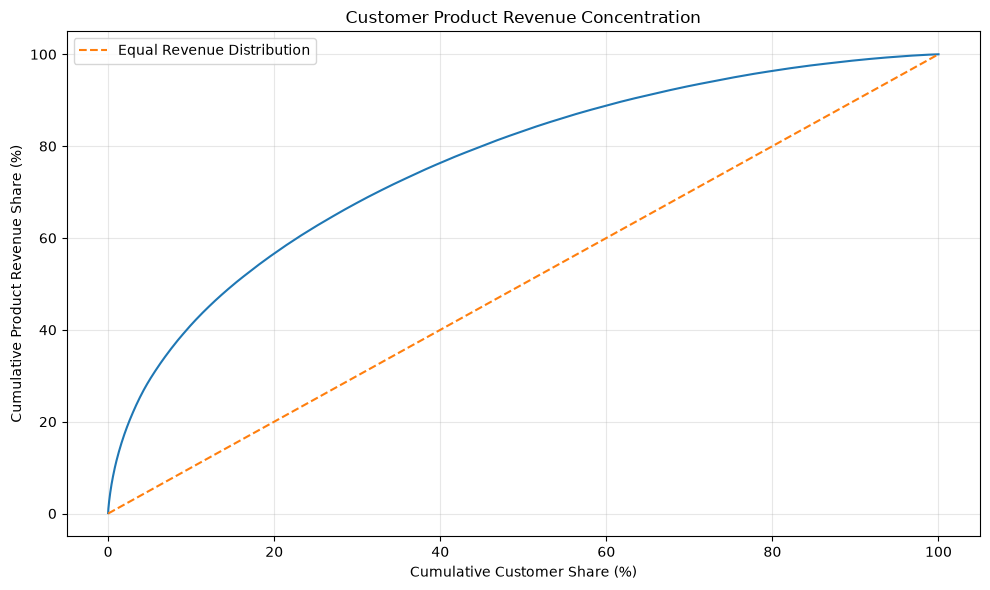

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(
    customer_value_ranked[
        "cumulative_customer_share_pct"
    ],
    customer_value_ranked[
        "cumulative_revenue_share_pct"
    ]
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Equal Revenue Distribution"
)

plt.xlabel("Cumulative Customer Share (%)")
plt.ylabel("Cumulative Product Revenue Share (%)")

plt.title(
    "Customer Product Revenue Concentration"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Customer Value Concentration — Key Findings

Customer monetary value is strongly right-skewed across the completed-order
customer base.

The median customer generated approximately **R$89.73** in cumulative product
revenue, compared with a substantially higher mean of approximately
**R$141.62**. The 99th percentile reached approximately **R$1,004.99**, while
the maximum observed customer value was **R$13,440.00**.

This indicates that a relatively small group of high-value customers raises the
overall average customer value substantially above the median.

Revenue concentration analysis shows that:

- The **top 1%** of customers generated approximately **11.47%** of product revenue
- The **top 5%** generated approximately **29.13%**
- The **top 10%** generated approximately **41.10%**
- The **top 20%** generated approximately **56.62%**

Product revenue is therefore meaningfully concentrated among higher-value
customers, although the concentration is not extreme enough to resemble a
traditional 80/20 pattern.

The cumulative concentration curve confirms this pattern. When customers are
ranked from highest to lowest product revenue, cumulative revenue grows faster
than cumulative customer share, indicating unequal economic contribution
across the customer base.

The highest-value customer generated **R$13,440.00** from a single completed
order. More broadly, most of the ten highest-value customers placed only one
completed order, demonstrating that high observed customer monetary value is
not necessarily associated with repeat purchasing.

Overall, customer prioritization should consider both monetary contribution
and purchase behavior rather than assuming that repeat customers are always
the highest-value customers.

#### Business Interpretation

The concentration results suggest that customer value is unevenly distributed,
but revenue is not dependent on only a very small group of customers.

The top 10% of customers contribute approximately **41.10%** of product
revenue, making high-value customers an important group for targeted
engagement. However, the remaining 90% of customers still generate the
majority of revenue.

This supports a tiered customer strategy rather than focusing exclusively on
the highest-value customers.

The presence of several high-value one-time customers also suggests that
monetary value and repeat behavior should be evaluated separately when
designing retention and second-purchase initiatives.

## 7. RFM Customer Segmentation

RFM analysis segments customers according to three dimensions of purchasing
behavior:

- **Recency (R):** How recently the customer placed their latest completed order
- **Frequency (F):** How many completed orders the customer placed
- **Monetary (M):** How much cumulative product revenue the customer generated

The analysis uses `customer_unique_id` as the persistent customer identifier
and includes only completed orders.

Because customer purchase frequency is highly concentrated at one completed
order, the distributions of all three RFM metrics are examined before assigning
customer scores or segments.

### 7.1 Define the RFM Reference Date

Recency requires a fixed reference point from which each customer's latest
completed purchase is measured.

Because the dataset contains historical transactions, the current calendar date
is not used. Instead, the reference date is derived from the latest completed
purchase timestamp in the analytical dataset.

One calendar day is added to the latest observed purchase date so that
customers purchasing on the final observed date have a positive recency value.

In [64]:
print(
    "Earliest completed purchase:",
    customer_order_value["order_purchase_timestamp"].min()
)

print(
    "Latest completed purchase:",
    customer_order_value["order_purchase_timestamp"].max()
)

Earliest completed purchase: 2016-09-15 12:16:38
Latest completed purchase: 2018-08-29 15:00:37


In [65]:
latest_purchase_date = (
    customer_order_value["order_purchase_timestamp"]
    .max()
    .normalize()
)

rfm_reference_date = (
    latest_purchase_date
    + pd.Timedelta(days=1)
)

print("Latest completed purchase date:", latest_purchase_date)
print("RFM reference date:", rfm_reference_date)

Latest completed purchase date: 2018-08-29 00:00:00
RFM reference date: 2018-08-30 00:00:00


#### RFM Reference Date — Key Findings

Completed-order purchases span from **September 15, 2016** to
**August 29, 2018**.

The RFM reference date is set to **August 30, 2018**, one calendar day after
the latest completed purchase date in the dataset.

Using a fixed dataset-based reference date ensures that Recency reflects each
customer's position within the observed transaction history rather than the
date on which the notebook is executed.

Under this definition, customers whose latest completed purchase occurred on
the final observed purchase date have a Recency of **1 day**.

### 7.2 Construct the RFM Base Table

The completed-order transaction dataset is aggregated by
`customer_unique_id` to construct the customer-level RFM dataset.

The three RFM metrics are defined as:

- **Recency:** Number of calendar days between the RFM reference date and the
  customer's most recent completed purchase
- **Frequency:** Number of distinct completed orders placed by the customer
- **Monetary:** Total product revenue generated by the customer across
  completed orders

Product revenue is defined consistently with the previous sales and customer
value analyses as the sum of item-level `price` values, excluding freight
charges.

The resulting dataset is expected to contain one row per unique completed-order
customer.

#### 7.2.1 Aggregate Customer Transactions

In [66]:
rfm = (
    customer_order_value
    .groupby("customer_unique_id")
    .agg(
        last_purchase_timestamp=(
            "order_purchase_timestamp",
            "max"
        ),
        frequency=(
            "order_id",
            "nunique"
        ),
        monetary=(
            "product_revenue",
            "sum"
        )
    )
    .reset_index()
)

#### 7.2.2 Calculate Customer Recency

Each customer's latest completed purchase timestamp is converted to a calendar
date before calculating Recency.

Recency is measured as the number of calendar days between the fixed RFM
reference date and the customer's latest completed purchase date.

Lower Recency therefore indicates a more recent customer.

In [67]:
rfm["last_purchase_date"] = (
    rfm["last_purchase_timestamp"]
    .dt.normalize()
)

rfm["recency_days"] = (
    rfm_reference_date
    - rfm["last_purchase_date"]
).dt.days

In [68]:
rfm.head()

,customer_unique_id,last_purchase_timestamp,frequency,monetary,last_purchase_date,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,2018-05-10,112
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,2018-05-07,115
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,2017-03-10,538
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,2017-10-12,322
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,2017-11-14,289


#### 7.2.3 Validate the RFM Customer Grain

Before analyzing or scoring the RFM metrics, the resulting dataset is validated
to confirm that each row represents one unique customer and that all required
RFM values are present.

In [69]:
print("RFM customer records:", len(rfm))

print(
    "Unique customer IDs:",
    rfm["customer_unique_id"].nunique()
)

print(
    "Duplicate customer IDs:",
    rfm["customer_unique_id"].duplicated().sum()
)

print(
    "Missing recency:",
    rfm["recency_days"].isna().sum()
)

print(
    "Missing frequency:",
    rfm["frequency"].isna().sum()
)

print(
    "Missing monetary:",
    rfm["monetary"].isna().sum()
)

RFM customer records: 93358
Unique customer IDs: 93358
Duplicate customer IDs: 0
Missing recency: 0
Missing frequency: 0
Missing monetary: 0


#### 7.2.4 Validate Recency

In [70]:
print(
    "Minimum recency:",
    rfm["recency_days"].min()
)

print(
    "Maximum recency:",
    rfm["recency_days"].max()
)

print(
    "Negative recency values:",
    (rfm["recency_days"] < 0).sum()
)

print(
    "Zero recency values:",
    (rfm["recency_days"] == 0).sum()
)

Minimum recency: 1
Maximum recency: 714
Negative recency values: 0
Zero recency values: 0


#### 7.2.5 Reconcile RFM Metrics

Frequency and Monetary values are reconciled with the previously validated
customer-value dataset.

This ensures that constructing the RFM table does not change the number of
completed orders or the amount of completed-sales product revenue represented
in the analysis.

In [71]:
print(
    "Completed orders represented in RFM:",
    rfm["frequency"].sum()
)

print(
    f"Product revenue represented in RFM: "
    f"R${rfm['monetary'].sum():,.2f}"
)

Completed orders represented in RFM: 96478
Product revenue represented in RFM: R$13,221,498.11


In [72]:
rfm_validation = rfm.merge(
    customer_value[
        [
            "customer_unique_id",
            "completed_orders",
            "product_revenue"
        ]
    ],
    on="customer_unique_id",
    how="left",
    validate="one_to_one"
)

In [73]:
frequency_mismatches = (
    rfm_validation["frequency"]
    != rfm_validation["completed_orders"]
).sum()

In [74]:
monetary_mismatches = (
    ~np.isclose(
        rfm_validation["monetary"],
        rfm_validation["product_revenue"],
        rtol=1e-9,
        atol=1e-6
    )
).sum()

In [75]:
print(
    "Frequency mismatches:",
    frequency_mismatches
)

print(
    "Monetary mismatches:",
    monetary_mismatches
)

Frequency mismatches: 0
Monetary mismatches: 0


#### RFM Base Table Validation — Key Findings

The RFM base table contains **93,358 unique customers**, with exactly one
record per `customer_unique_id`.

No duplicate customer identifiers or missing Recency, Frequency, or Monetary
values were identified.

Customer Recency ranges from **1 to 714 days** relative to the fixed RFM
reference date of August 30, 2018. No zero or negative Recency values were
observed, confirming that the reference-date calculation is internally
consistent.

The RFM dataset represents all **96,478 completed orders** and preserves
**R$13,221,498.11** in completed-sales product revenue.

Customer-level reconciliation against the previously validated customer-value
dataset produced **zero Frequency mismatches** and **zero Monetary mismatches**.

These validations confirm that the RFM base table preserves the completed-order
customer population, transaction counts, and product revenue required for
customer segmentation.

### 7.3 RFM Metric Distributions

Before assigning RFM scores, the distributions of Recency, Frequency, and
Monetary value are examined.

This step is necessary because the three metrics may have substantially
different distributions. In particular, the previous purchase-frequency
analysis showed that most completed-order customers placed only one order.

Applying the same quantile-based scoring method mechanically to all three
metrics could therefore create artificial or unstable customer groups.

The metric distributions are first evaluated to determine an appropriate
scoring strategy for each RFM dimension.

#### 7.3.1 Summary Statistics

In [76]:
rfm_summary = (
    rfm[
        [
            "recency_days",
            "frequency",
            "monetary"
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

rfm_summary

,recency_days,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,238.478877,1.033420,141.621480
std,152.595054,0.209097,215.694014
min,1.000000,1.000000,0.850000
25%,115.000000,1.000000,47.650000
50%,219.000000,1.000000,89.730000
75%,347.000000,1.000000,154.737500
90%,466.000000,1.000000,279.990000
95%,520.000000,1.000000,419.809000
99%,576.000000,2.000000,1004.990000


#### 7.3.2 Frequency Distribution

Frequency requires additional examination because completed-order purchasing
is heavily concentrated among one-time customers.

The exact Frequency distribution is therefore evaluated before determining the
Frequency scoring method.

In [77]:
rfm_frequency_distribution = (
    rfm["frequency"]
    .value_counts()
    .sort_index()
    .rename_axis("frequency")
    .reset_index(name="customers")
)

rfm_frequency_distribution["customer_share_pct"] = (
    rfm_frequency_distribution["customers"]
    / len(rfm)
    * 100
)

rfm_frequency_distribution

,frequency,customers,customer_share_pct
0,1,90557,96.999722
1,2,2573,2.756057
2,3,181,0.193877
3,4,28,0.029992
4,5,9,0.009640
5,6,5,0.005356
6,7,3,0.003213
7,9,1,0.001071
8,15,1,0.001071


#### 7.3.3 RFM Quantile Boundaries

Quartile boundaries are examined before applying any scoring rules.

If multiple quantile boundaries contain the same value, a standard
quantile-based scoring approach may not meaningfully separate customers for
that metric.

In [78]:
rfm_quantiles = (
    rfm[
        [
            "recency_days",
            "frequency",
            "monetary"
        ]
    ]
    .quantile(
        [
            0.25,
            0.50,
            0.75
        ]
    )
)

rfm_quantiles

,recency_days,frequency,monetary
0.25,115.0,1.0,47.6500
0.50,219.0,1.0,89.7300
0.75,347.0,1.0,154.7375


#### 7.3.4 Frequency Quantile Feasibility Check

In [79]:
frequency_quartile_boundaries = (
    rfm["frequency"]
    .quantile([0.25, 0.50, 0.75])
)

print(
    "Frequency quartile boundaries:"
)

print(
    frequency_quartile_boundaries
)

print(
    "\nUnique quartile boundary values:",
    frequency_quartile_boundaries.nunique()
)

Frequency quartile boundaries:
0.25    1.0
0.50    1.0
0.75    1.0
Name: frequency, dtype: float64

Unique quartile boundary values: 1


#### 7.3.5 Recency and Monetary Quantile Feasibility

In [80]:
for metric in ["recency_days", "monetary"]:
    boundaries = (
        rfm[metric]
        .quantile([0.25, 0.50, 0.75])
    )

    print(f"{metric} quartile boundaries:")
    print(boundaries)

    print(
        "Unique quartile boundary values:",
        boundaries.nunique()
    )

    print()

recency_days quartile boundaries:
0.25    115.0
0.50    219.0
0.75    347.0
Name: recency_days, dtype: float64
Unique quartile boundary values: 3

monetary quartile boundaries:
0.25     47.6500
0.50     89.7300
0.75    154.7375
Name: monetary, dtype: float64
Unique quartile boundary values: 3



#### RFM Metric Distribution — Key Findings

The three RFM dimensions exhibit substantially different distributions.

**Recency** ranges from **1 to 714 days**, with quartile boundaries at
**115, 219, and 347 days**. The distinct quartile boundaries indicate that
Recency can be meaningfully divided into four customer groups based on how
recently customers purchased.

**Frequency**, however, is extremely concentrated. Approximately **97.00%**
of customers placed exactly one completed order, while **2.76%** placed two
orders and only a very small proportion placed three or more. Consequently,
the 25th, 50th, and 75th percentiles of Frequency are all equal to **1**.

This makes standard quartile-based Frequency scoring unsuitable because it
cannot meaningfully distinguish the majority of customers.

**Monetary** value is strongly right-skewed. The median customer generated
approximately **R$89.73** in product revenue, compared with a mean of
approximately **R$141.62**. The 99th percentile reaches approximately
**R$1,004.99**, while the maximum customer value is **R$13,440.00**.

Unlike Frequency, Monetary has distinct quartile boundaries at approximately
**R$47.65, R$89.73, and R$154.74**, allowing meaningful quantile-based
segmentation.

Based on these distributions, Recency and Monetary can be scored using
quartiles, while Frequency requires a custom behavior-based scoring approach.

### 7.4 RFM Scoring Methodology

#### 7.4.1 Define the Scoring Strategy
The RFM scoring methodology is adapted to the observed distribution of each
customer metric rather than applying an identical scoring rule mechanically
across all three dimensions.

The scoring strategy is defined as follows:

| Metric | Scoring Method | Interpretation |
|---|---|---|
| Recency | Quartile-based, 1–4 | More recent customers receive higher scores |
| Frequency | Behavior-based, 1–3 | Customers with more completed orders receive higher scores |
| Monetary | Quartile-based, 1–4 | Higher-value customers receive higher scores |

For Recency, lower values indicate more recent purchasing behavior and
therefore receive higher scores.

For Monetary, higher cumulative product revenue indicates greater customer
value and therefore receives higher scores.

Frequency is not scored using quartiles because approximately 97% of customers
placed only one completed order. Instead, customers are grouped according to
their observed purchase behavior:

- **F = 1:** One completed order
- **F = 2:** Two completed orders
- **F = 3:** Three or more completed orders

This approach preserves meaningful behavioral differences without artificially
splitting customers who have identical purchase frequencies.

#### 7.4.2 Recency Score

Recency is divided into four groups using the observed quartile boundaries.

Because lower Recency represents more recent purchasing activity, the scoring
direction is reversed so that the most recent customers receive the highest
score.

| Recency | R Score |
|---|---:|
| ≤ 115 days | 4 |
| 116–219 days | 3 |
| 220–347 days | 2 |
| > 347 days | 1 |

In [81]:
recency_q25 = rfm["recency_days"].quantile(0.25)
recency_q50 = rfm["recency_days"].quantile(0.50)
recency_q75 = rfm["recency_days"].quantile(0.75)

print("Recency Q25:", recency_q25)
print("Recency Q50:", recency_q50)
print("Recency Q75:", recency_q75)

Recency Q25: 115.0
Recency Q50: 219.0
Recency Q75: 347.0


In [82]:
def assign_recency_score(recency):
    if recency <= recency_q25:
        return 4
    elif recency <= recency_q50:
        return 3
    elif recency <= recency_q75:
        return 2
    else:
        return 1


rfm["r_score"] = (
    rfm["recency_days"]
    .apply(assign_recency_score)
)

#### 7.4.3 Frequency Score

Frequency is scored using observed purchase behavior rather than quartiles.

Customers with one completed order receive the lowest Frequency score,
customers with two completed orders receive the middle score, and customers
with three or more completed orders receive the highest score.

This avoids artificially separating the large number of customers who share
the same purchase frequency.

In [83]:
def assign_frequency_score(frequency):
    if frequency == 1:
        return 1
    elif frequency == 2:
        return 2
    else:
        return 3


rfm["f_score"] = (
    rfm["frequency"]
    .apply(assign_frequency_score)
)

#### 7.4.4 Monetary Score

Monetary value is divided into four groups using customer-level product-revenue
quartiles.

Higher cumulative product revenue represents greater observed customer value
and therefore receives a higher Monetary score.

| Monetary Value | M Score |
|---|---:|
| ≤ 25th percentile | 1 |
| 25th–50th percentile | 2 |
| 50th–75th percentile | 3 |
| > 75th percentile | 4 |

In [84]:
monetary_q25 = rfm["monetary"].quantile(0.25)
monetary_q50 = rfm["monetary"].quantile(0.50)
monetary_q75 = rfm["monetary"].quantile(0.75)

print("Monetary Q25:", monetary_q25)
print("Monetary Q50:", monetary_q50)
print("Monetary Q75:", monetary_q75)

Monetary Q25: 47.65
Monetary Q50: 89.73
Monetary Q75: 154.7375


In [85]:
def assign_monetary_score(monetary):
    if monetary <= monetary_q25:
        return 1
    elif monetary <= monetary_q50:
        return 2
    elif monetary <= monetary_q75:
        return 3
    else:
        return 4


rfm["m_score"] = (
    rfm["monetary"]
    .apply(assign_monetary_score)
)

In [86]:
rfm["m_score"].value_counts().sort_index()

m_score
1    23341
2    23338
3    23339
4    23340
Name: count, dtype: int64

#### 7.4.5 Create the RFM Score Profile

The individual Recency, Frequency, and Monetary scores are preserved rather
than relying only on a single combined score.

Customers with the same total RFM score may exhibit substantially different
purchase behaviors. For example, a recent one-time high-value customer may
receive a similar total score to an older repeat customer.

An RFM profile code is therefore created to retain the behavioral information
contained in all three dimensions. A total score is also calculated for
descriptive purposes, but it is not used as the sole basis for customer
segmentation.

In [87]:
rfm["rfm_code"] = (
    "R" + rfm["r_score"].astype(str)
    + "F" + rfm["f_score"].astype(str)
    + "M" + rfm["m_score"].astype(str)
)

rfm["rfm_total_score"] = (
    rfm["r_score"]
    + rfm["f_score"]
    + rfm["m_score"]
)

In [88]:
rfm[
    [
        "customer_unique_id",
        "recency_days",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score",
        "rfm_code",
        "rfm_total_score"
    ]
].head(10)

,customer_unique_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_code,rfm_total_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,3,R4F1M3,8
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,R4F1M1,6
2,0000f46a3911fa3c0805444483337064,538,1,69.00,1,1,2,R1F1M2,4
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,25.99,2,1,1,R2F1M1,4
4,0004aac84e0df4da2b147fca70cf8255,289,1,180.00,2,1,4,R2F1M4,7
5,0004bd2a26a76fe21f786e4fbd80607f,147,1,154.00,3,1,3,R3F1M3,7
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,27.99,3,1,1,R3F1M1,5
7,00053a61a98854899e70ed204dd4bafe,183,1,382.00,3,1,4,R3F1M4,8
8,0005e1862207bf6ccc02e4228effd9a0,544,1,135.00,1,1,3,R1F1M3,5
9,0005ef4cd20d2893f0d9fbd94d3c0d97,171,1,104.90,3,1,3,R3F1M3,7


#### 7.4.6 Validate RFM Score Distributions

The assigned scores are validated to confirm that all customers receive valid
RFM classifications and that the resulting score distributions are consistent
with the scoring methodology.

Recency and Monetary are expected to form approximately equal-sized quartile
groups, while Frequency is expected to remain highly concentrated in the
lowest score because of the large share of one-time customers.

In [89]:
r_score_distribution = (
    rfm["r_score"]
    .value_counts()
    .sort_index()
)

r_score_distribution

r_score
1    23269
2    23409
3    23129
4    23551
Name: count, dtype: int64

In [90]:
f_score_distribution = (
    rfm["f_score"]
    .value_counts()
    .sort_index()
)

f_score_distribution

f_score
1    90557
2     2573
3      228
Name: count, dtype: int64

#### 7.4.7 Final Score Validation

In [91]:
print(
    "R Score range:",
    rfm["r_score"].min(),
    "to",
    rfm["r_score"].max()
)

print(
    "F Score range:",
    rfm["f_score"].min(),
    "to",
    rfm["f_score"].max()
)

print(
    "M Score range:",
    rfm["m_score"].min(),
    "to",
    rfm["m_score"].max()
)

print(
    "RFM Total Score range:",
    rfm["rfm_total_score"].min(),
    "to",
    rfm["rfm_total_score"].max()
)

print(
    "Missing RFM scores:",
    rfm[
        [
            "r_score",
            "f_score",
            "m_score"
        ]
    ].isna().sum().sum()
)

print(
    "RFM customers represented:",
    len(rfm)
)

R Score range: 1 to 4
F Score range: 1 to 3
M Score range: 1 to 4
RFM Total Score range: 3 to 11
Missing RFM scores: 0
RFM customers represented: 93358


In [92]:
print(
    "R Score customers:",
    r_score_distribution.sum()
)

print(
    "F Score customers:",
    f_score_distribution.sum()
)

print(
    "M Score customers:",
    rfm["m_score"].value_counts().sum()
)

R Score customers: 93358
F Score customers: 93358
M Score customers: 93358


#### RFM Scoring Validation — Key Findings

All **93,358 completed-order customers** were successfully assigned Recency,
Frequency, and Monetary scores with no missing classifications.

Recency scores range from **1 to 4** and form approximately equal-sized groups.
Minor differences in group size occur because customers with identical Recency
values are assigned to the same score rather than being artificially separated
across quartiles.

Frequency scores range from **1 to 3** and intentionally preserve the highly
concentrated purchase-frequency structure of the customer base. A total of
**90,557 customers** received F1, **2,573 customers** received F2, and only
**228 customers** received F3.

Monetary scores range from **1 to 4** and form approximately equal-sized
quartile groups based on cumulative completed-order product revenue.

The resulting combined RFM total score ranges from **3 to 11**. However,
customer segmentation will preserve the individual R, F, and M dimensions
rather than relying solely on this summed score, because customers with similar
total scores may exhibit substantially different purchasing behaviors.

### 7.5 Customer Segmentation
#### 7.5.1 Define Customer Segments

The RFM scores are translated into business-oriented customer segments.

Because approximately 97% of customers placed only one completed order,
segmentation places particular emphasis on distinguishing between one-time and
repeat purchasing behavior while using Recency and Monetary scores to identify
differences in customer activity and value.

Six mutually exclusive segments are defined:

| Segment | Definition | Interpretation |
|---|---|---|
| High-Value Repeat | F ≥ 2 and M = 4 | Repeat customers with the highest observed monetary value |
| Active Repeat | F ≥ 2, M < 4, and R ≥ 3 | Repeat customers with relatively recent purchasing activity |
| Inactive Repeat | F ≥ 2, M < 4, and R ≤ 2 | Repeat customers whose latest purchase occurred less recently |
| Recent High-Value One-Time | F = 1, R ≥ 3, and M = 4 | Recent high-value customers who have not yet repeated |
| Recent One-Time | F = 1, R ≥ 3, and M < 4 | Recent customers with only one completed order |
| Inactive One-Time | F = 1 and R ≤ 2 | One-time customers whose latest purchase occurred less recently |

These segments preserve the behavioral meaning of the individual RFM
dimensions rather than relying solely on the summed RFM score.

#### 7.5.2 Assign Customer Segments

The defined segmentation rules are applied to each customer based on their
Recency, Frequency, and Monetary scores.

Each customer is assigned to exactly one mutually exclusive segment.

In [93]:
def assign_customer_segment(row):
    if row["f_score"] >= 2 and row["m_score"] == 4:
        return "High-Value Repeat"

    elif (
        row["f_score"] >= 2
        and row["m_score"] < 4
        and row["r_score"] >= 3
    ):
        return "Active Repeat"

    elif (
        row["f_score"] >= 2
        and row["m_score"] < 4
        and row["r_score"] <= 2
    ):
        return "Inactive Repeat"

    elif (
        row["f_score"] == 1
        and row["r_score"] >= 3
        and row["m_score"] == 4
    ):
        return "Recent High-Value One-Time"

    elif (
        row["f_score"] == 1
        and row["r_score"] >= 3
        and row["m_score"] < 4
    ):
        return "Recent One-Time"

    else:
        return "Inactive One-Time"


rfm["customer_segment"] = (
    rfm.apply(
        assign_customer_segment,
        axis=1
    )
)

#### 7.5.3 Validate Segment Assignment

In [94]:
print(
    "Customers segmented:",
    rfm["customer_segment"].notna().sum()
)

print(
    "Missing segments:",
    rfm["customer_segment"].isna().sum()
)

print(
    "Unique segments:",
    rfm["customer_segment"].nunique()
)

print(
    "Total RFM customers:",
    len(rfm)
)

Customers segmented: 93358
Missing segments: 0
Unique segments: 6
Total RFM customers: 93358


#### 7.5.4 Segment Distribution

In [95]:
segment_distribution = (
    rfm["customer_segment"]
    .value_counts()
    .rename_axis("customer_segment")
    .reset_index(name="customers")
)

segment_distribution["customer_share_pct"] = (
    segment_distribution["customers"]
    / len(rfm)
    * 100
)

segment_distribution

,customer_segment,customers,customer_share_pct
0,Inactive One-Time,45420,48.651428
1,Recent One-Time,34410,36.858116
2,Recent High-Value One-Time,10727,11.490178
3,High-Value Repeat,1679,1.798453
4,Active Repeat,577,0.618051
5,Inactive Repeat,545,0.583774


#### 7.5.5 Customer Segment Profile

In [96]:
segment_profile = (
    rfm
    .groupby("customer_segment")
    .agg(
        customers=(
            "customer_unique_id",
            "nunique"
        ),
        avg_recency_days=(
            "recency_days",
            "mean"
        ),
        avg_frequency=(
            "frequency",
            "mean"
        ),
        avg_monetary=(
            "monetary",
            "mean"
        ),
        total_monetary=(
            "monetary",
            "sum"
        )
    )
    .reset_index()
)

In [97]:
segment_profile["customer_share_pct"] = (
    segment_profile["customers"]
    / segment_profile["customers"].sum()
    * 100
)

segment_profile["revenue_share_pct"] = (
    segment_profile["total_monetary"]
    / segment_profile["total_monetary"].sum()
    * 100
)

In [98]:
segment_profile[
    [
        "customer_segment",
        "customers",
        "customer_share_pct",
        "avg_recency_days",
        "avg_frequency",
        "avg_monetary",
        "total_monetary",
        "revenue_share_pct"
    ]
].sort_values(
    "revenue_share_pct",
    ascending=False
)

,customer_segment,customers,customer_share_pct,avg_recency_days,avg_frequency,avg_monetary,total_monetary,revenue_share_pct
2,Inactive One-Time,45420,48.651428,364.984390,1.000000,137.736560,6255994.55,47.316836
4,Recent High-Value One-Time,10727,11.490178,112.312016,1.000000,353.289673,3789738.32,28.663456
5,Recent One-Time,34410,36.858116,112.265679,1.000000,71.123409,2447356.49,18.510433
1,High-Value Repeat,1679,1.798453,212.385944,2.157832,369.094741,619710.07,4.687140
0,Active Repeat,577,0.618051,112.608319,2.045061,97.253345,56115.18,0.424424
3,Inactive Repeat,545,0.583774,361.313761,2.051376,96.483486,52583.50,0.397712


#### 7.5.6 Reconcile Segment Results

In [99]:
print(
    "Customers represented:",
    segment_profile["customers"].sum()
)

print(
    f"Product revenue represented: "
    f"R${segment_profile['total_monetary'].sum():,.2f}"
)

print(
    "Customer share total:",
    round(
        segment_profile["customer_share_pct"].sum(),
        2
    )
)

print(
    "Revenue share total:",
    round(
        segment_profile["revenue_share_pct"].sum(),
        2
    )
)

Customers represented: 93358
Product revenue represented: R$13,221,498.11
Customer share total: 100.0
Revenue share total: 100.0


#### Customer Segmentation — Key Findings

All **93,358 completed-order customers** were successfully assigned to one of
six mutually exclusive RFM-based customer segments. The segmentation preserves
the full customer population and **R$13,221,498.11** in completed-sales product
revenue.

The customer base remains heavily concentrated among one-time purchasers.
**Inactive One-Time** customers represent **48.65%** of customers and
**47.32%** of product revenue, while **Recent One-Time** customers represent
another **36.86%** of customers but only **18.51%** of revenue.

A particularly important segment is **Recent High-Value One-Time** customers.
Although they represent only **11.49%** of customers, they contribute
approximately **28.66%** of product revenue and generate an average of
approximately **R$353.29** per customer. Their relatively recent purchasing
activity and high observed monetary value make this group a potentially
important target for second-purchase initiatives.

**High-Value Repeat** customers represent only **1.80%** of the customer base
but contribute approximately **4.69%** of product revenue. Their average
customer monetary value of approximately **R$369.09** is the highest among the
six segments, highlighting the cumulative value associated with customers who
combine repeat purchasing with high monetary value.

In contrast, **Active Repeat** and **Inactive Repeat** customers have average
monetary values of approximately **R$97.25** and **R$96.48**, respectively.
This demonstrates that repeat purchasing alone does not necessarily indicate
high customer value.

Overall, the segmentation reveals that customer value cannot be explained by
purchase frequency alone. A substantial share of revenue is generated by
high-value one-time customers, while a much smaller group combines both repeat
purchasing and high cumulative monetary value.

### 7.6 Business Interpretation of RFM Segments

The RFM segments provide different opportunities for customer engagement.

| Customer Segment | Business Interpretation | Potential Action |
|---|---|---|
| High-Value Repeat | Small but highly valuable repeat-customer group | Prioritize retention, relationship maintenance, and personalized offers |
| Active Repeat | Recent repeat purchasers with moderate observed monetary value | Encourage continued purchasing and monitor value development |
| Inactive Repeat | Customers who previously repeated but have not purchased recently | Consider re-engagement or win-back initiatives |
| Recent High-Value One-Time | Recent high-value purchasers without an observed repeat order | Prioritize second-purchase conversion initiatives |
| Recent One-Time | Recent first-time purchasers with lower or moderate observed value | Use scalable follow-up and repeat-purchase campaigns |
| Inactive One-Time | Older one-time customers with no observed repeat purchase | Use selective reactivation strategies rather than high-cost retention efforts |

These actions should be interpreted as analytical recommendations rather than
causal predictions. The RFM model describes observed customer behavior within
the available transaction history and does not predict whether an individual
customer will purchase again.

### 7.7 RFM Segment Visualization

In [100]:
segment_comparison = (
    segment_profile[
        [
            "customer_segment",
            "customer_share_pct",
            "revenue_share_pct"
        ]
    ]
    .sort_values(
        "revenue_share_pct",
        ascending=True
    )
)

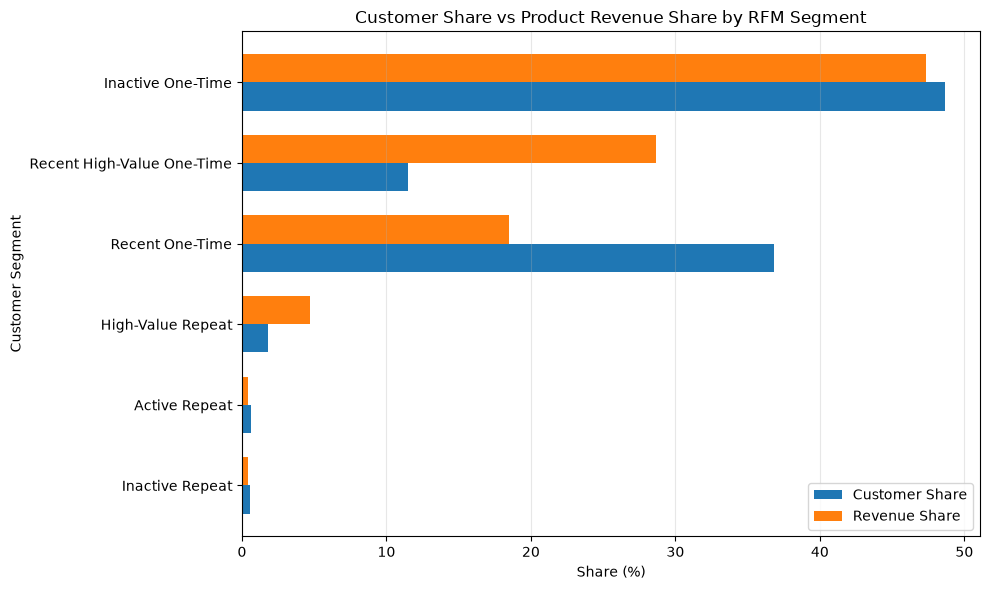

In [101]:
y = np.arange(len(segment_comparison))
bar_height = 0.35

plt.figure(figsize=(10, 6))

plt.barh(
    y - bar_height / 2,
    segment_comparison["customer_share_pct"],
    height=bar_height,
    label="Customer Share"
)

plt.barh(
    y + bar_height / 2,
    segment_comparison["revenue_share_pct"],
    height=bar_height,
    label="Revenue Share"
)

plt.yticks(
    y,
    segment_comparison["customer_segment"]
)

plt.xlabel("Share (%)")
plt.ylabel("Customer Segment")
plt.title("Customer Share vs Product Revenue Share by RFM Segment")

plt.legend()
plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

#### RFM Segment Comparison — Key Findings

The comparison between customer share and product-revenue share highlights
substantial differences in economic contribution across RFM segments.

The strongest positive imbalance is observed among **Recent High-Value
One-Time** customers. This segment represents only **11.49%** of customers but
contributes approximately **28.66%** of completed-sales product revenue.

**High-Value Repeat** customers show a similar pattern on a smaller scale,
representing **1.80%** of customers while contributing approximately **4.69%**
of product revenue.

By contrast, **Recent One-Time** customers account for **36.86%** of the
customer base but only **18.51%** of product revenue.

These differences demonstrate why customer count alone is insufficient for
prioritizing customer groups. Combining purchase recency, repeat behavior, and
monetary value provides a more informative basis for identifying customer
segments with different economic contributions and engagement opportunities.

## 8. Customer Analysis Summary & Business Insights

This section consolidates the main findings from the completed-order customer
analysis, including purchase frequency, repeat behavior, customer monetary
value, revenue concentration, and RFM segmentation.

The objective is to translate the analytical results into a concise view of
customer behavior and potential business priorities while recognizing the
limitations of the available transaction history.

### 8.1 Customer Behavior Summary

The completed-order customer base contains **93,358 unique customers**
associated with **96,478 completed orders**.

Customer purchasing behavior is heavily concentrated among one-time buyers.
Approximately **97.00%** of customers placed exactly one completed order during
the observed dataset period, while only **3.00%** placed two or more completed
orders.

Although repeat customers represented only **3.00%** of the customer base,
they generated approximately **6.14%** of completed orders.

Repeat purchasing was also relatively shallow. Among the **2,801 repeat
customers**, approximately **91.86%** placed exactly two completed orders,
while only **8.14%** placed three or more.

The median observed time between the first and second completed purchases was
approximately **28.98 days**. Approximately **50.41%** of observed second
purchases occurred within 30 days.

However, **30.45%** occurred within one day, and validation identified multiple
distinct orders sharing the same customer and purchase timestamp. Some
short-interval repeat purchases may therefore represent multiple orders placed
within the same shopping session rather than conventional customer return
behavior.

Overall, the observed customer base is characterized by a large one-time
customer population and relatively limited sustained repeat purchasing.

### 8.2 Customer Value & Concentration

Repeat customers generated higher cumulative product revenue per customer than
one-time customers.

Average cumulative product revenue was approximately **R$260.05 per repeat
customer**, compared with approximately **R$137.96 per one-time customer**.

However, repeat customers did not generate higher product revenue per completed
order. Their average product revenue per completed order was approximately
**R$123.02**, compared with approximately **R$137.96** for one-time customers.

The higher cumulative value of repeat customers was therefore primarily
associated with purchasing more frequently rather than generating more product
revenue on each completed order.

Customer monetary value was also strongly right-skewed. Median cumulative
product revenue was approximately **R$89.73**, compared with a mean of
approximately **R$141.62**. The 99th percentile reached approximately
**R$1,004.99**, while the maximum observed customer value was **R$13,440.00**.

Revenue was meaningfully, but not extremely, concentrated among higher-value
customers:

- The **top 1%** of customers generated approximately **11.47%** of product revenue
- The **top 5%** generated approximately **29.13%**
- The **top 10%** generated approximately **41.10%**
- The **top 20%** generated approximately **56.62%**

Most of the ten highest-value customers placed only one completed order,
further demonstrating that high monetary value is not necessarily associated
with repeat purchasing.

Overall, customer value should be evaluated using both monetary contribution
and purchase behavior rather than repeat status alone.

### 8.3 RFM Segment Insights

RFM segmentation further demonstrates that customer value cannot be explained
by purchase frequency alone.

The most notable opportunity is the **Recent High-Value One-Time** segment.
These customers represent only **11.49%** of the customer base but contribute
approximately **28.66%** of completed-sales product revenue. Their average
customer monetary value is approximately **R$353.29**.

This group has demonstrated relatively recent and high-value purchasing
behavior but has not yet placed a second completed order within the observed
transaction history.

**High-Value Repeat** customers represent only **1.80%** of customers but
contribute approximately **4.69%** of product revenue. Their average customer
monetary value of approximately **R$369.09** is the highest among the six RFM
segments.

In contrast, **Recent One-Time** customers account for **36.86%** of the
customer base but only **18.51%** of product revenue.

The comparison between customer share and revenue share therefore reveals
substantial differences in economic contribution across customer groups.

These findings support the use of Recency, Frequency, and Monetary value
together when prioritizing customer segments rather than relying on purchase
frequency alone.

### 8.4 Business Recommendations

Based on the observed customer behavior and value patterns, the analysis
suggests several potential business priorities.

**1. Prioritize second-purchase initiatives for recent high-value one-time customers**

Recent High-Value One-Time customers combine relatively recent purchasing
activity with high monetary value but have not yet placed a second completed
order. Because this segment contributes disproportionately to product revenue,
it represents a potentially important audience for targeted second-purchase
initiatives.

Potential actions may include personalized follow-up offers, product
recommendations, or time-sensitive incentives designed to encourage another
purchase.

**2. Protect the small high-value repeat customer base**

High-Value Repeat customers represent a small share of the customer base but
generate disproportionately high cumulative monetary value.

Retention-oriented initiatives, personalized engagement, or priority customer
experiences may therefore be particularly relevant for maintaining
relationships with this group.

**3. Avoid treating all repeat customers as equally valuable**

Repeat purchasing alone does not imply high monetary value. Active and
Inactive Repeat customers have substantially lower average monetary values than
High-Value Repeat customers.

Customer prioritization should therefore consider both purchase frequency and
monetary contribution.

**4. Use scalable engagement for the large one-time customer population**

One-time customers represent approximately **97%** of completed-order
customers. Because this population is both large and heterogeneous, uniform
high-cost retention efforts may be inefficient.

Recency and Monetary value can instead be used to prioritize different levels
of engagement, with higher-value and more recent customers receiving greater
attention.

**5. Maintain a broad customer strategy alongside high-value targeting**

Although the top 10% of customers generate approximately **41.10%** of product
revenue, the remaining 90% still contribute the majority of revenue.

The concentration results therefore support a tiered customer strategy rather
than focusing exclusively on a small group of highest-value customers.

### 8.5 Analytical Limitations

The customer analysis should be interpreted within the limitations of the
available transaction history.

First, the dataset represents a finite observation period. Customers whose
first purchase occurred earlier in the dataset had more time to place
additional orders than customers whose first purchase occurred near the end of
the observation window. Therefore, the observed **3.00% repeat purchase rate**
should not be interpreted as a long-term customer retention rate.

Second, some distinct completed orders occurred within very short intervals,
including multiple orders sharing the same customer and purchase timestamp.
These transactions were retained because they represent distinct orders in the
dataset, but some may reflect multiple purchases within the same shopping
session rather than conventional return behavior.

Third, Recency in the RFM analysis is measured relative to the fixed dataset
reference date of **August 30, 2018**. RFM segments therefore describe customer
behavior within the available historical period rather than current customer
status.

Finally, the RFM segmentation is descriptive rather than predictive. The
analysis identifies differences in observed customer behavior and economic
contribution but does not estimate customer lifetime value, churn probability,
or the likelihood of future purchases.

These limitations should be considered when translating the analytical
findings into retention, re-engagement, or marketing decisions.

In [102]:
customer_segments_export = rfm[
    [
        "customer_unique_id",
        "recency_days",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score",
        "rfm_code",
        "rfm_total_score",
        "customer_segment"
    ]
].copy()

customer_segments_export.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

print("Exported rows:", len(customer_segments_export))
print("Unique customers:", customer_segments_export["customer_unique_id"].nunique())
print("Missing segments:", customer_segments_export["customer_segment"].isna().sum())

customer_segments_export.head()

Exported rows: 93358
Unique customers: 93358
Missing segments: 0


,customer_unique_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_code,rfm_total_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,3,R4F1M3,8,Recent One-Time
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,R4F1M1,6,Recent One-Time
2,0000f46a3911fa3c0805444483337064,538,1,69.00,1,1,2,R1F1M2,4,Inactive One-Time
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,25.99,2,1,1,R2F1M1,4,Inactive One-Time
4,0004aac84e0df4da2b147fca70cf8255,289,1,180.00,2,1,4,R2F1M4,7,Inactive One-Time
